Notebook to do all the standard deviation plots for the thesis.

Boilerplate code here

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


Calculate Std deviation $\sigma$ of a sample

In [2]:
dir = 'G:/Testing/RPM-0.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/'
# dir = 'G:/Testing/RPM-1.0__Upiston-100__Stroke-100/2023-08-23__FPS-90/'
# dir = 'G:/Testing/RPM-12.0__Upiston-100__Stroke-100/2023-08-21__FPS-90/'
u, v = oj.load_multiple_rings(dir, 10)

u, v = oj.scaleVelNozzle(u, v, 90)
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[2], u.shape[3])

Time = oj.frames_to_seconds(u[1,:,:,:], v[1,:,:,:], 90)

stn_dev_u = np.std(u[1:,:,:,:], axis = 0)
stn_dev_v = np.std(v[1:,:,:,:], axis = 0)


Filtered Data Imported  -  (2699, 69, 111)
G:/Testing/RPM-0.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/ 
Filtered Data Imported  -  (2699, 69, 111)
[####                                    ]10%Filtered Data Imported  -  (2699, 69, 111)
[########                                ]20%Filtered Data Imported  -  (2699, 69, 111)
[############                            ]30%Filtered Data Imported  -  (2699, 69, 111)
[################                        ]40%Filtered Data Imported  -  (2699, 69, 111)
[####################                    ]50%Filtered Data Imported  -  (2699, 69, 111)
[########################                ]60%Filtered Data Imported  -  (2699, 69, 111)
[############################            ]70%Filtered Data Imported  -  (2699, 69, 111)
[################################        ]80%Filtered Data Imported  -  (2699, 69, 111)
[####################################    ]90%Filtered Data Imported  -  (2699, 69, 111)
[########################################]100%

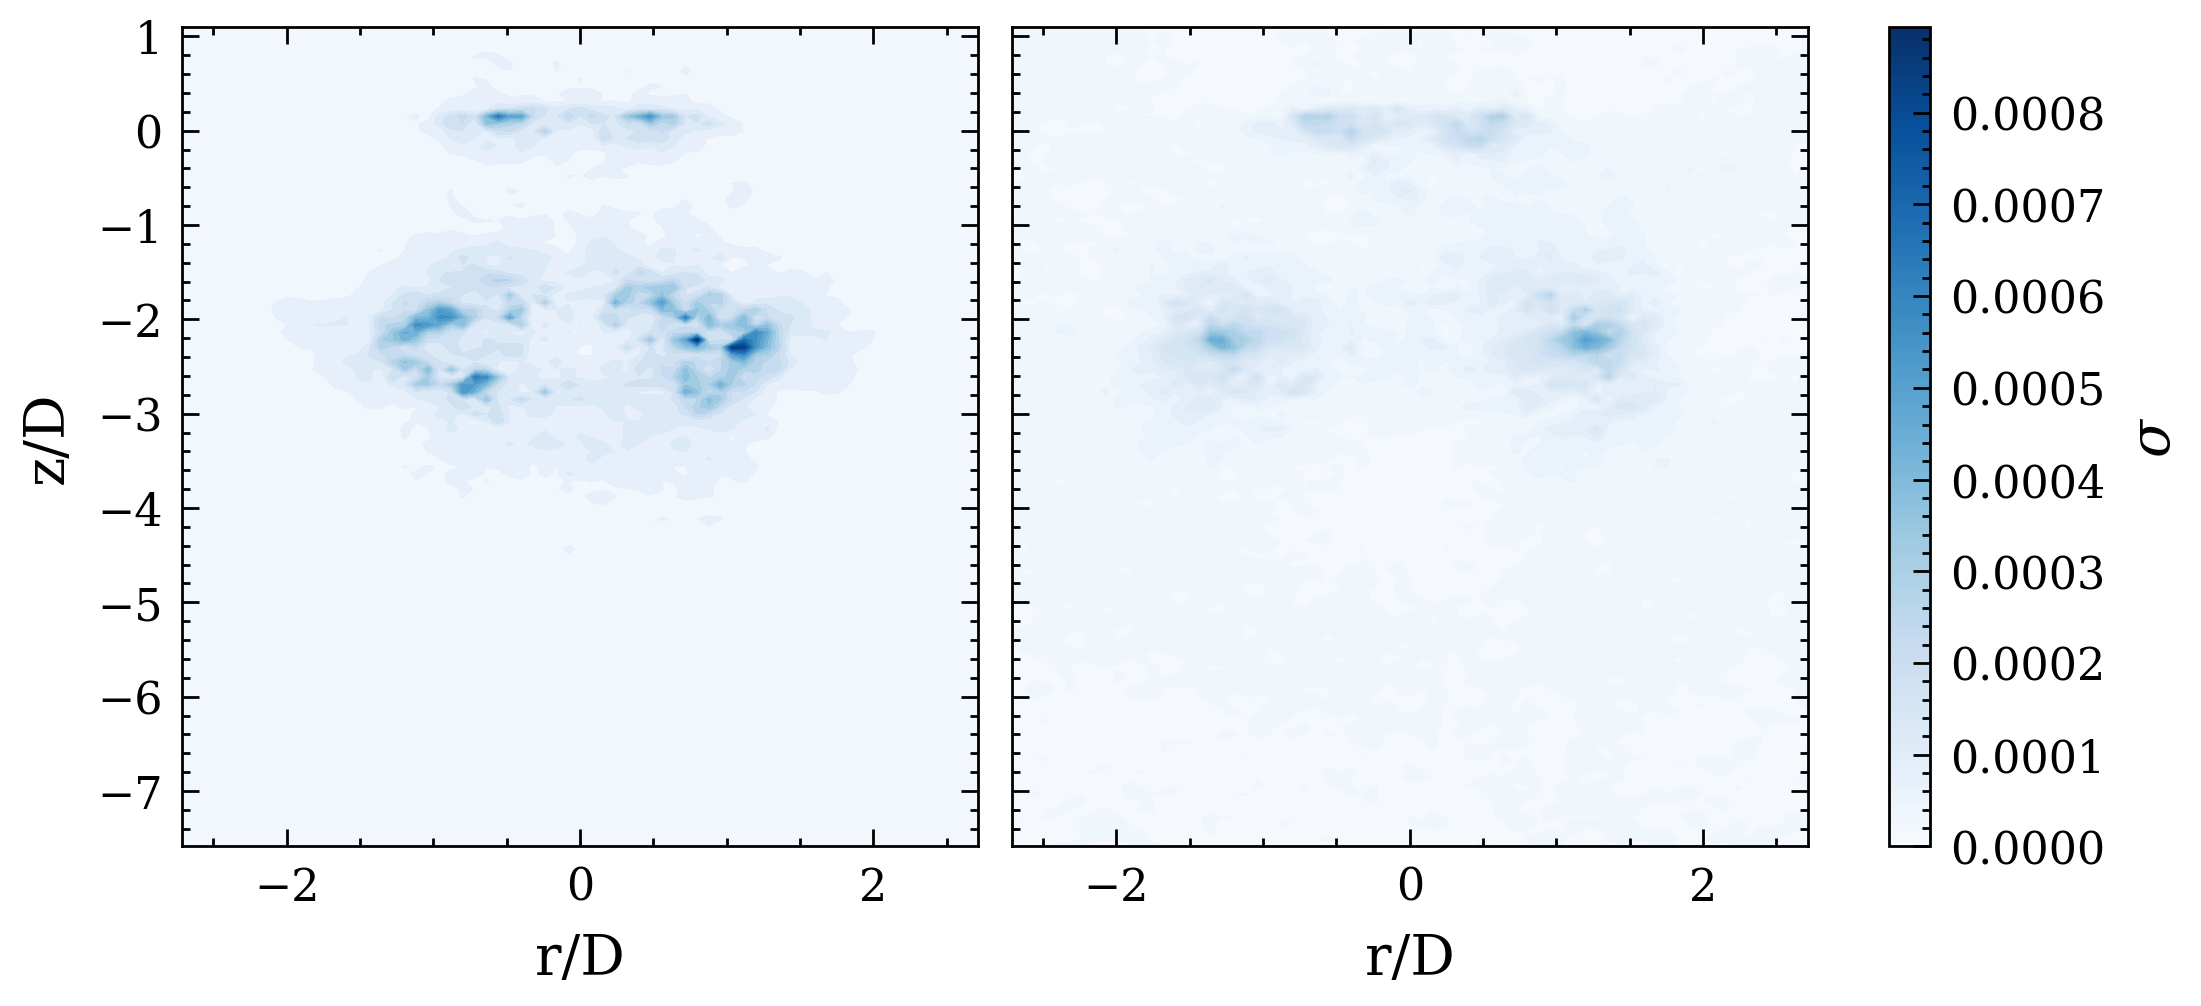

In [3]:
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[2], u.shape[3])

frame = 300

z_nd_top = z_nd[::-1]

vmin = np.min([stn_dev_u[frame,:,:], stn_dev_v[frame,:,:]])
vmax = np.max([stn_dev_u[frame,:,:], stn_dev_v[frame,:,:]])
norm = colors.TwoSlopeNorm(vmin=0, vcenter=vmax/2, vmax=vmax)

f1, ax = plt.subplots(1, 2, figsize=(5.5, 2.5))
ax[0].contourf(r_nd, -z_nd, np.rot90(stn_dev_u[frame,:,:],3), cmap = 'Blues', norm = norm, levels = 20)
ax[0].set_xlabel("r/D")
ax[0].set_ylabel("z/D")
ax[1].contourf(r_nd, -z_nd, np.rot90(stn_dev_v[frame,:,:],3), cmap = 'Blues', norm = norm, levels = 20)
ax[1].set_xlabel("r/D")
ax[1].set_yticklabels([])
cbar = f1.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='Blues'), ax=ax, label=r'$\sigma$' )
# cbar.set_label(r'$\sigma$', rotation=90)
plt.show()
# f1.savefig('//cantus.ads.warwick.ac.uk/User44/u/u2088308/Documents/My Pictures/Thesis Images/Ch5_Intial_and_Validation/Repeatability/std_dev_0rpm')

Plotting the standard deviation normalised by the Coefficient of Variation. CV = $\sigma/\mu$

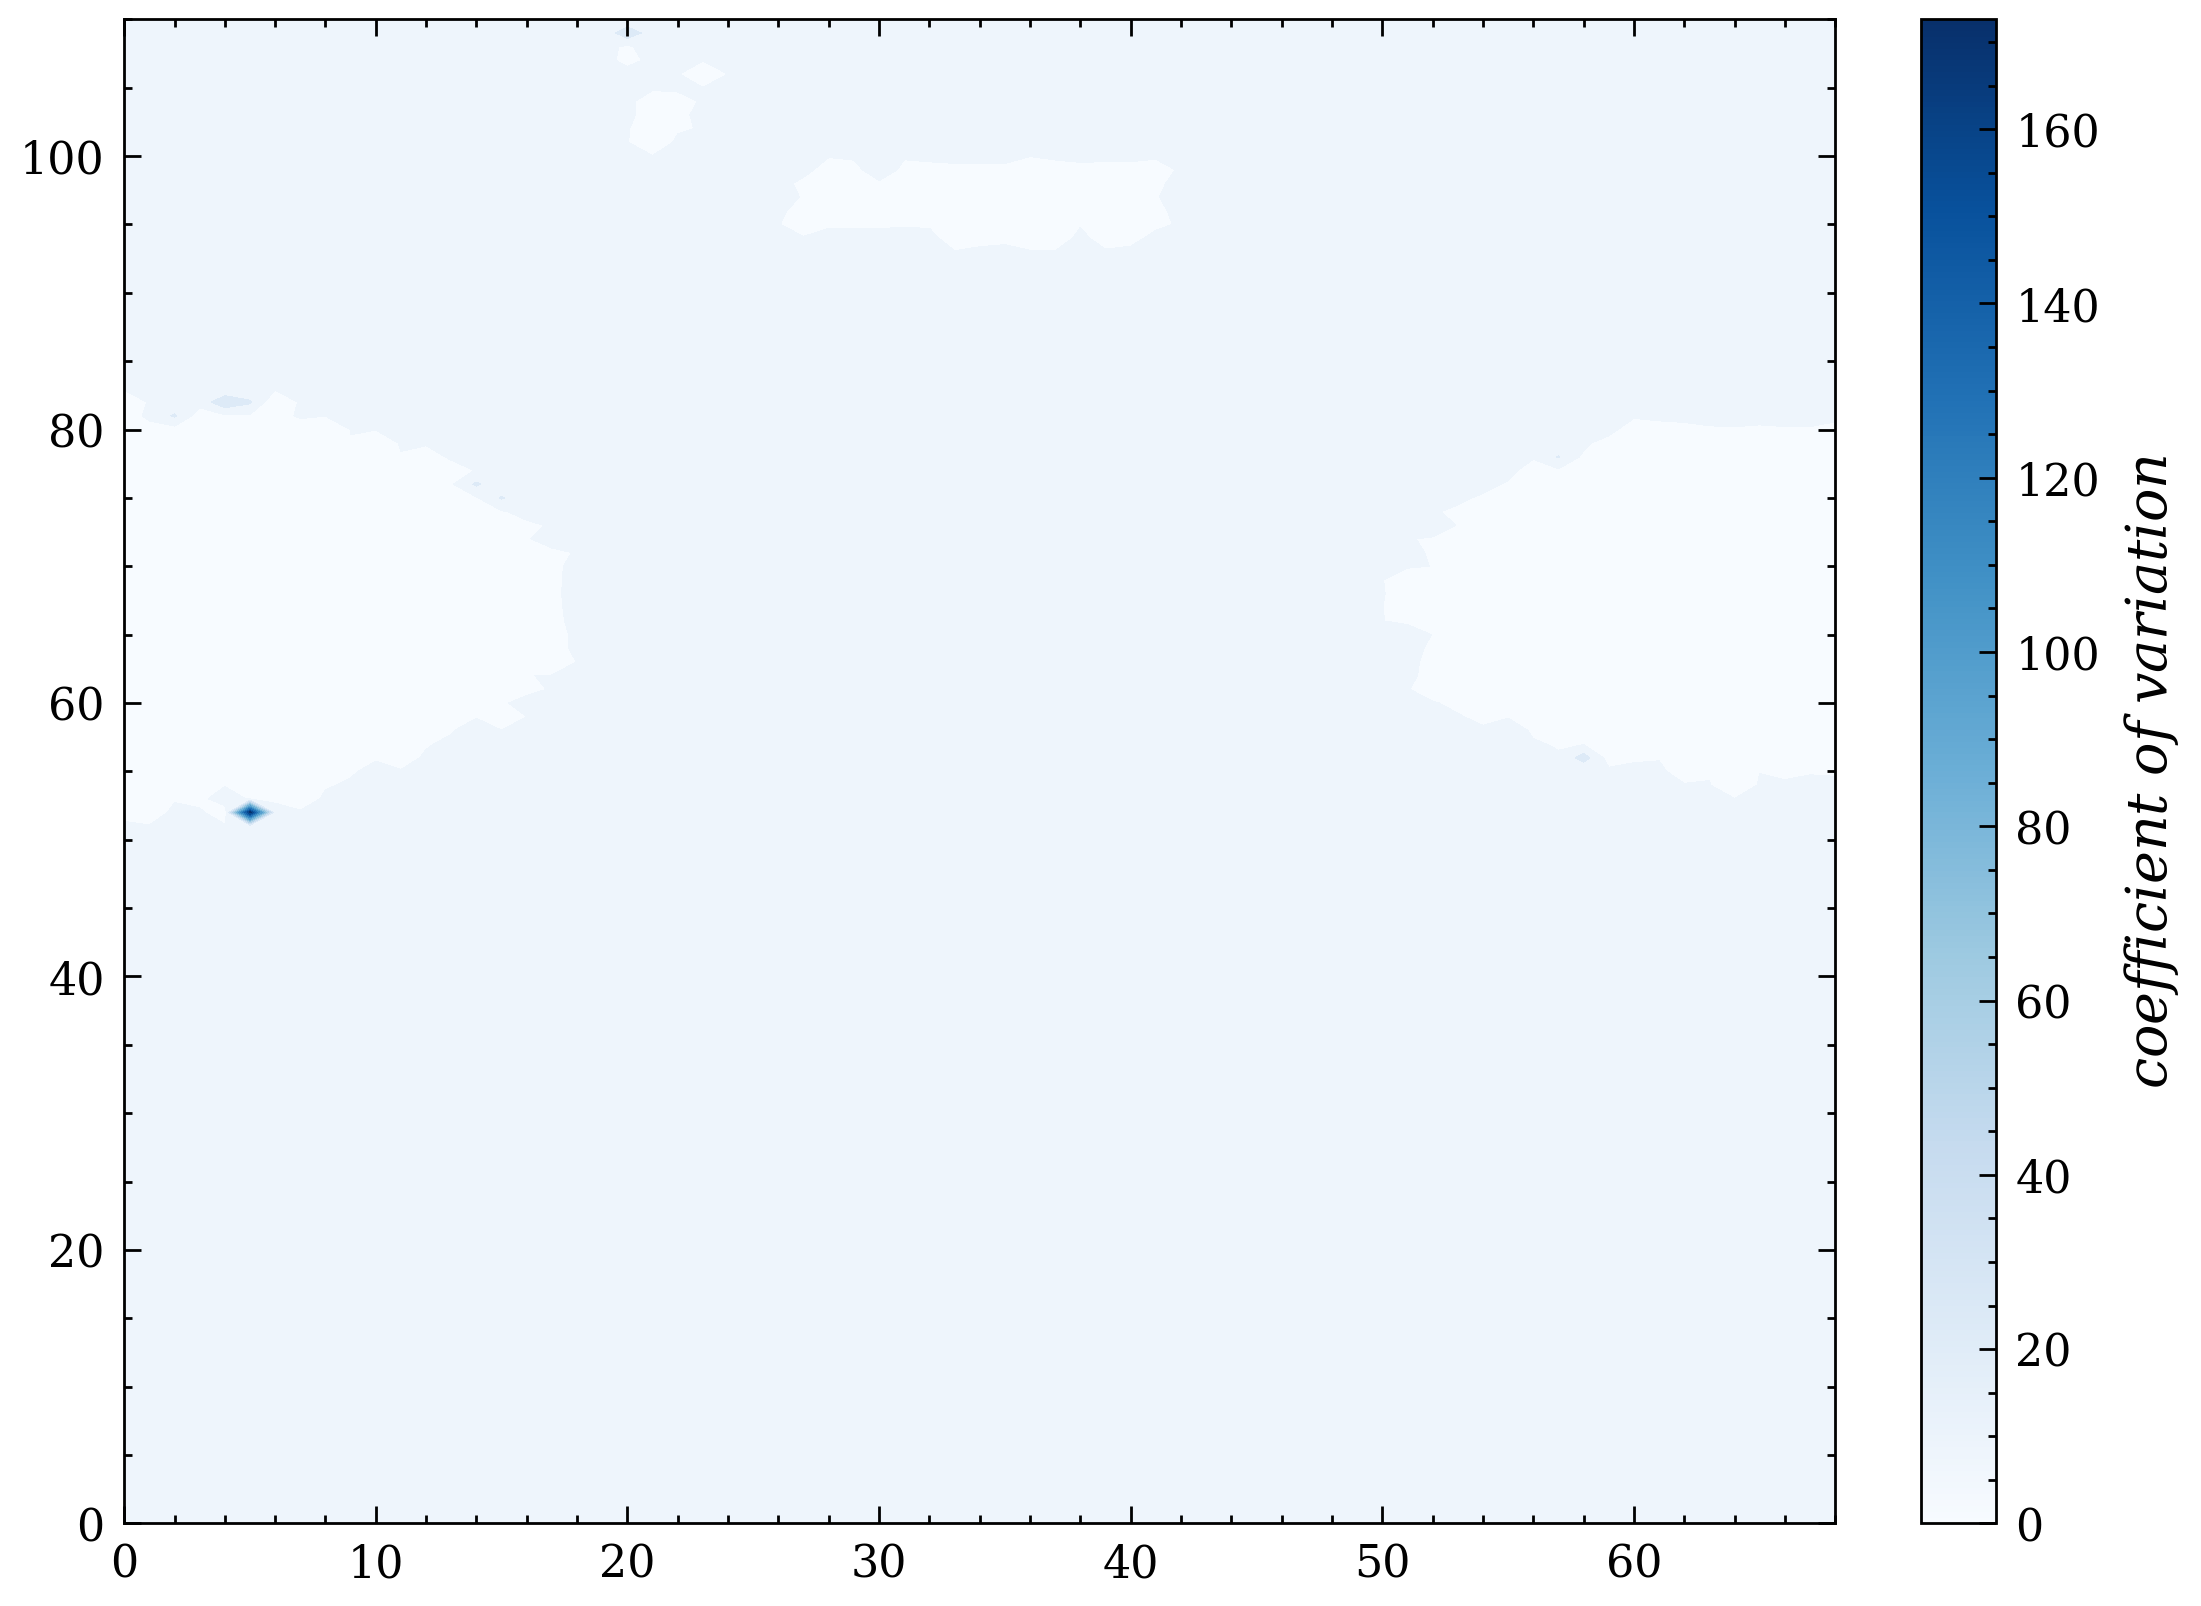

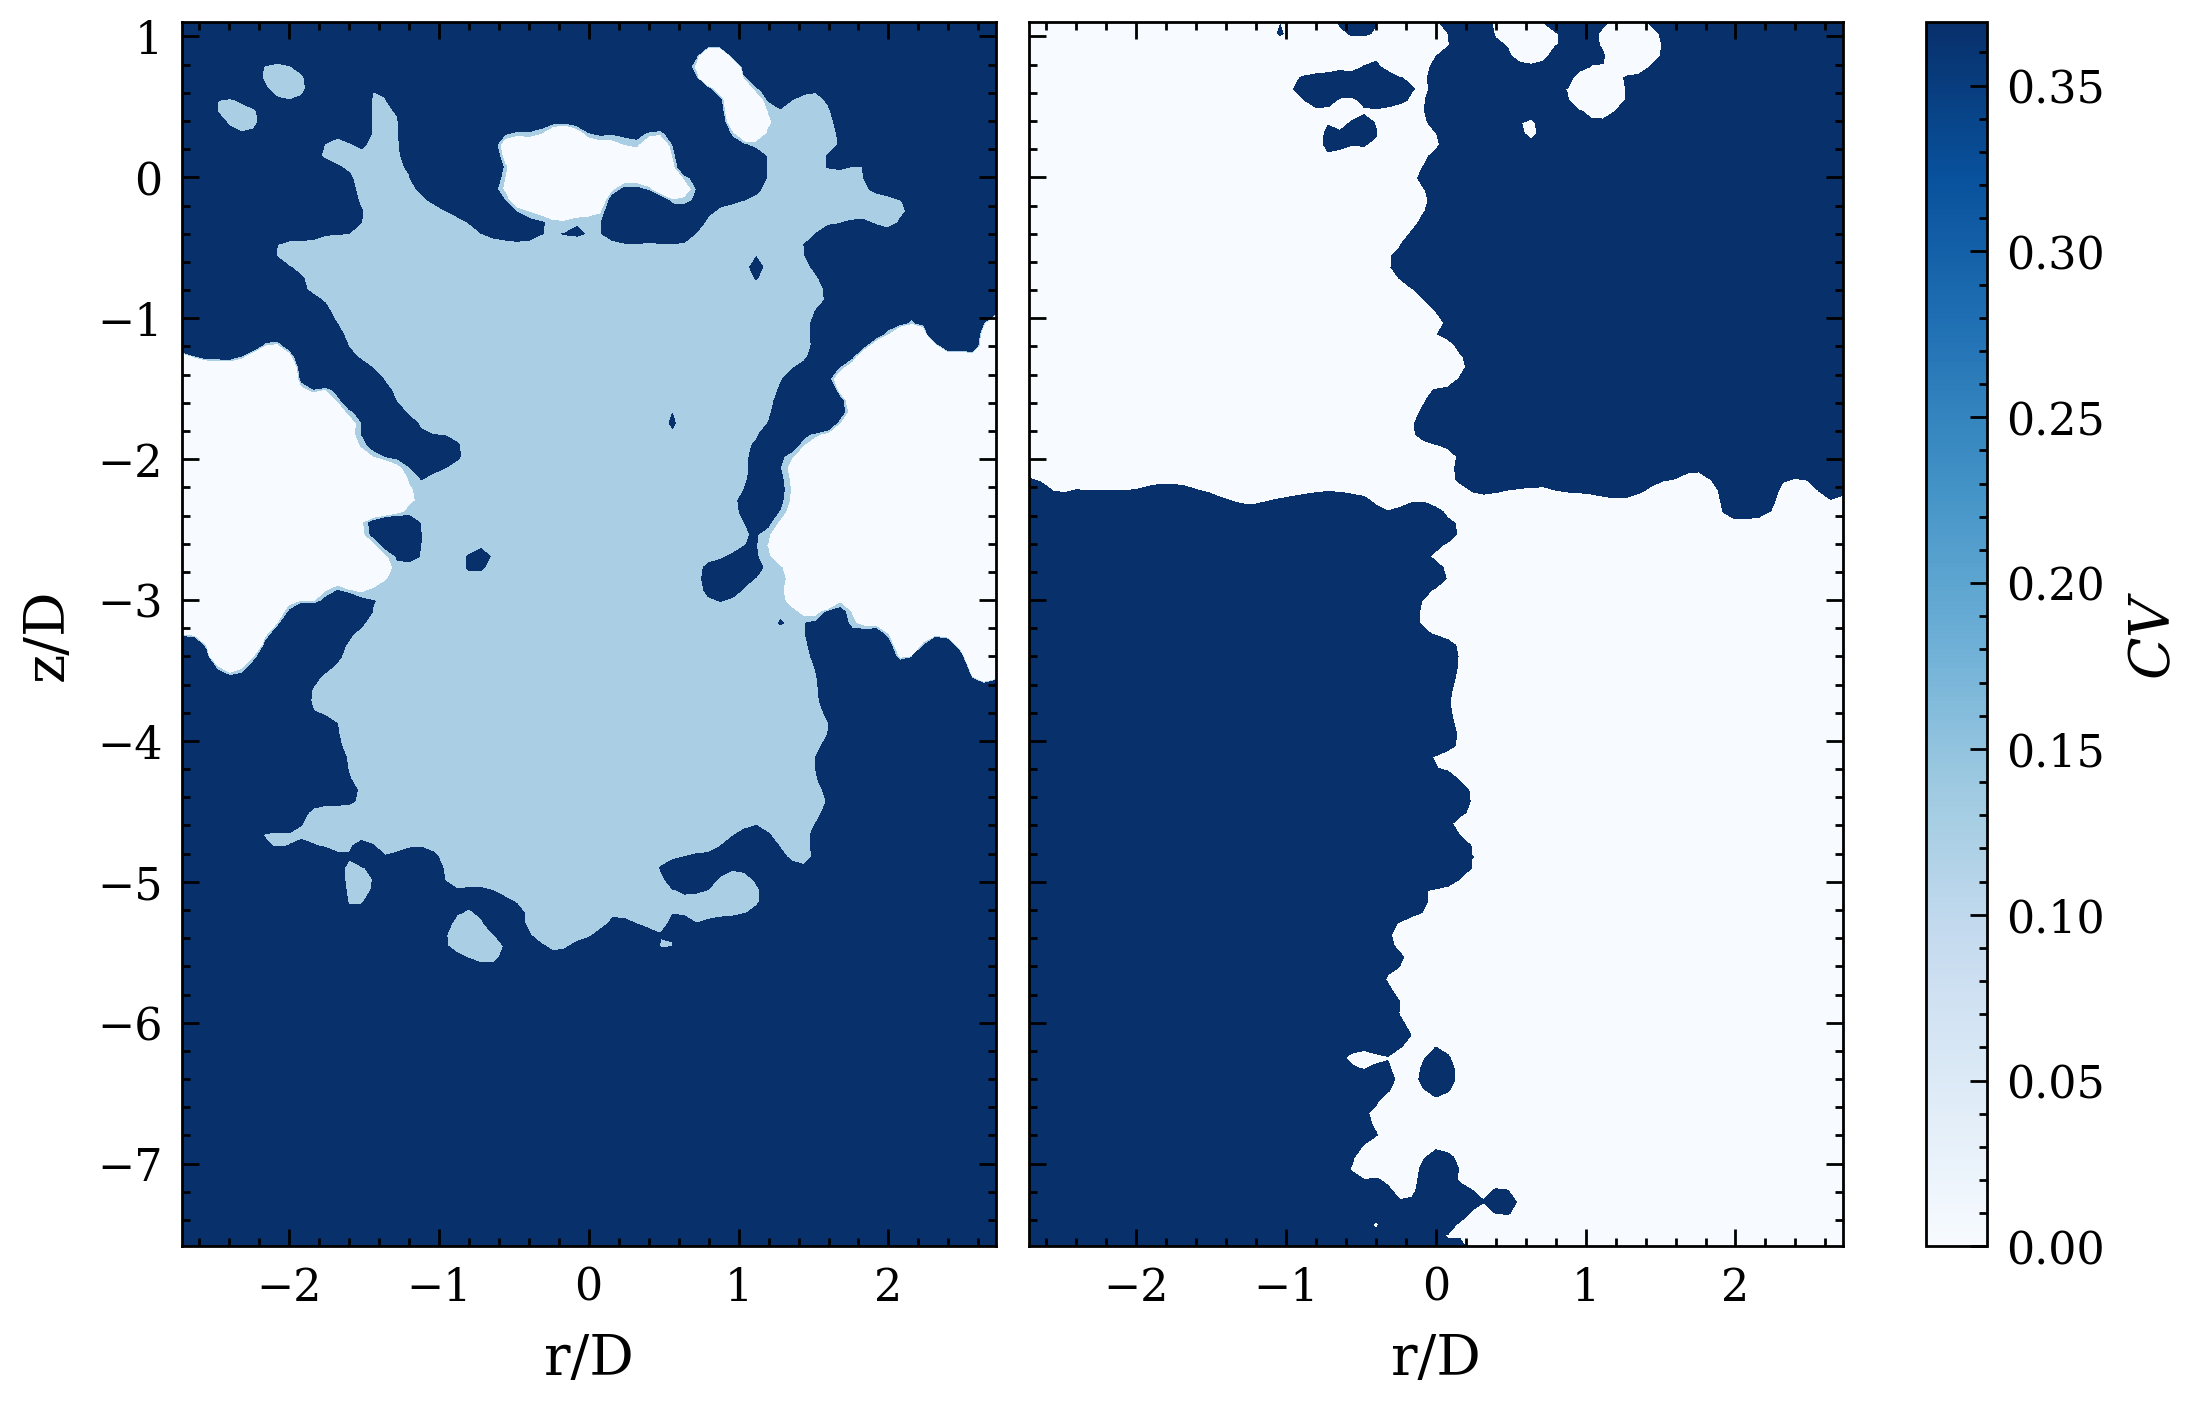

(10, 2699, 69, 111)


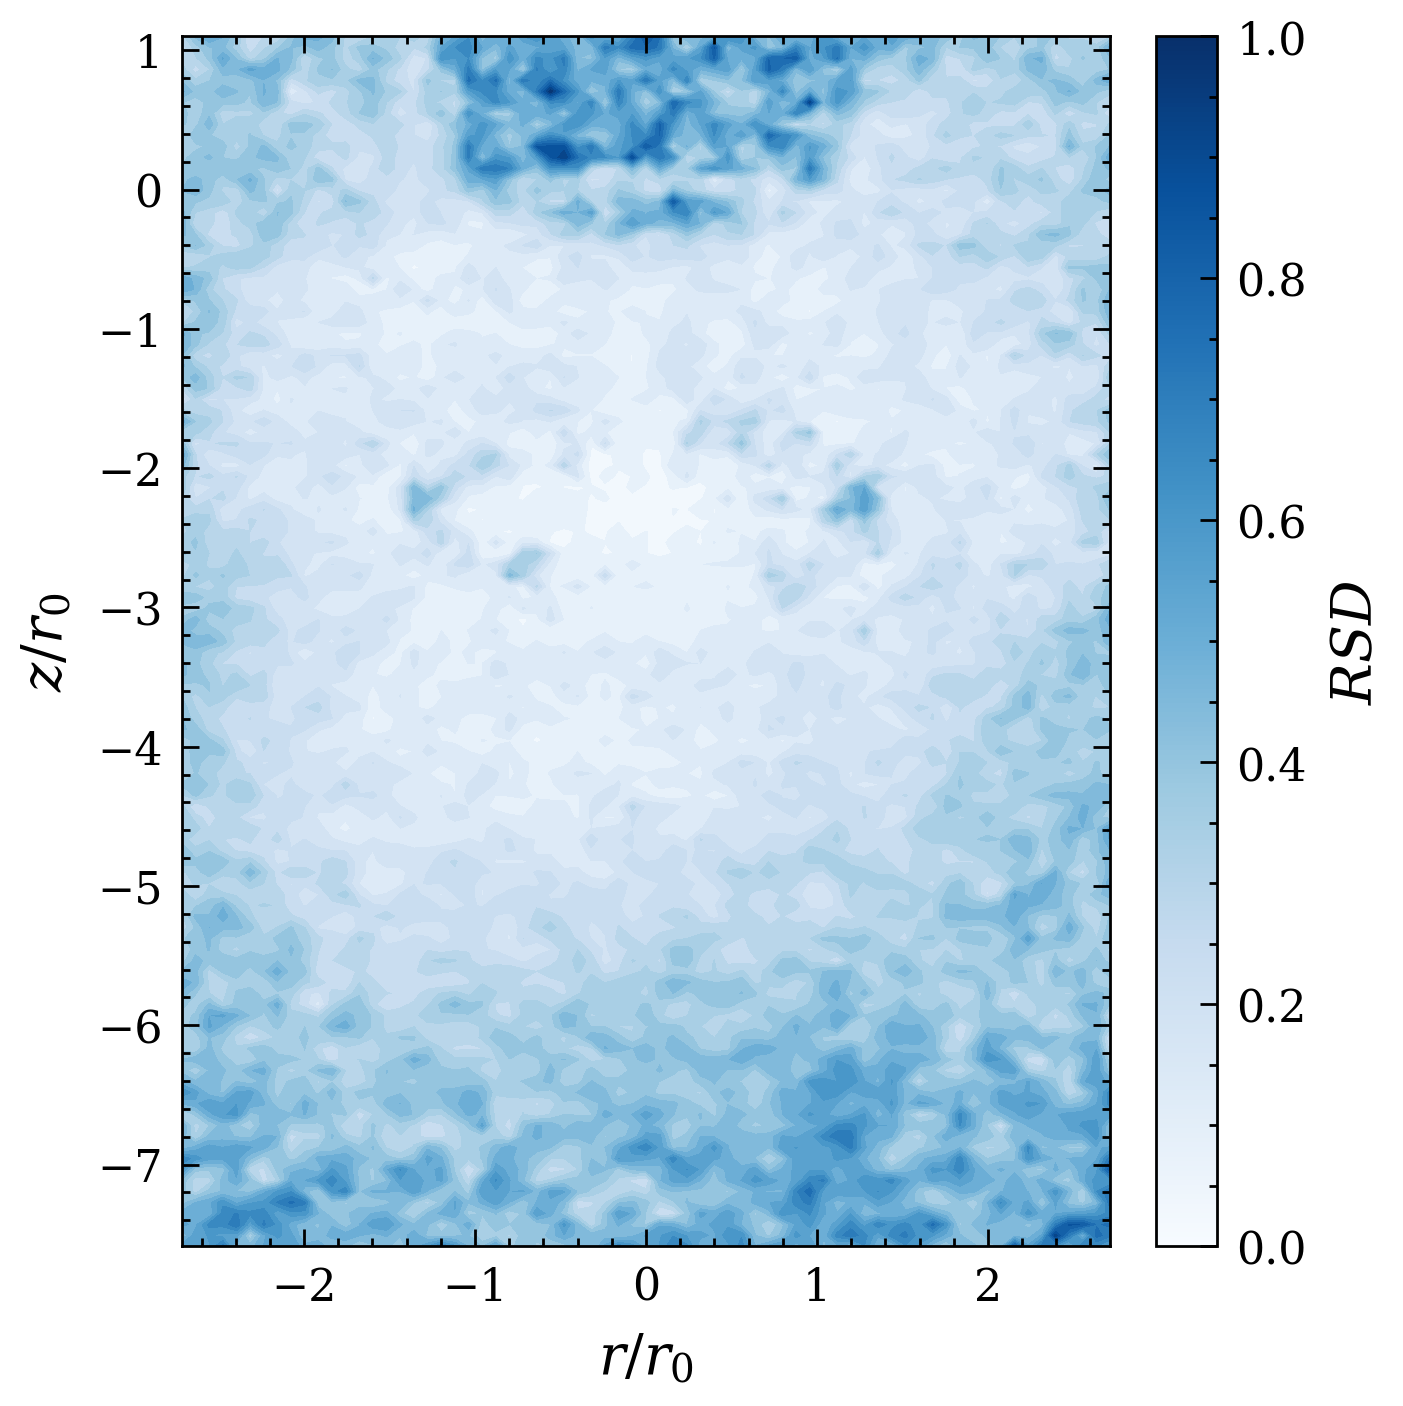

In [4]:
umean, vmean = np.mean(u[1:,:,:,:], axis = 0), np.mean(v[1:,:,:,:], axis = 0)
from scipy.ndimage import gaussian_filter

frame = 300
sigma = 100

vmin = np.min(stn_dev_u[frame,:,:]/umean[frame,:,:])
vmax = np.max(stn_dev_u[frame,:,:]/umean[frame,:,:])
norm = colors.TwoSlopeNorm(vmin=0, vcenter=vmax/2, vmax=vmax)

f4, ax4 = plt.subplots(nrows=1, ncols=1)
ax4.contourf(np.rot90((stn_dev_u[frame,:,:]/umean[frame,:,:])), cmap='Blues',norm = norm, levels = 20)
f4.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='Blues'), ax=ax4, label=r'$coefficient~ of~ variation$' )
plt.show()

vmin = np.min([gaussian_filter(stn_dev_u[frame,:,:]/umean[frame,:,:], sigma=sigma), gaussian_filter(stn_dev_v[frame,:,:]/vmean[frame,:,:], sigma=sigma)])
vmax = np.max([gaussian_filter(stn_dev_u[frame,:,:]/umean[frame,:,:], sigma=sigma), gaussian_filter(stn_dev_v[frame,:,:]/vmean[frame,:,:], sigma=sigma)])
norm = colors.TwoSlopeNorm(vmin=0, vcenter=vmax/2, vmax=vmax)

f1, axs = plt.subplots(1, 2, figsize=(5.5, 3.5))
axs[0].contourf(r_nd, -z_nd, gaussian_filter(np.rot90(stn_dev_u[frame,:,:]/umean[frame,:,:],3), sigma=1), cmap = 'Blues', norm = norm, levels = 200)
axs[0].set_xlabel("r/D")
axs[0].set_ylabel("z/D")
axs[1].contourf(r_nd, -z_nd, gaussian_filter(np.rot90(stn_dev_v[frame,:,:]/vmean[frame,:,:],3), sigma=1), cmap = 'Blues', norm = norm, levels = 200)
axs[1].set_xlabel("r/D")
axs[1].set_yticklabels([])
cbar = f1.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='Blues'), ax=axs, label=r'$CV$' )
# cbar.set_label(r'$\sigma$', rotation=90)
plt.show()


V = np.sqrt(u**2 + v**2)
print(V.shape)
sigmaV = np.std(V[1:,:,:,:], axis = 0)

Vmean = np.mean(V[1:,:,:,:], axis = 0)
f3, ax3 = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax3.contourf(r_nd, -z_nd, np.rot90(sigmaV[frame,:,:]/Vmean[frame,:,:],3), cmap = 'Blues', levels = 20)
ax3.set_xlabel(r"$r/r_{0}$")
ax3.set_ylabel(r"$z/r_{0}$")
cbar = f3.colorbar(matplotlib.cm.ScalarMappable(cmap='Blues'), ax=ax3, label=r'$RSD$' )
plt.show()

Making a histogram of values of sigma

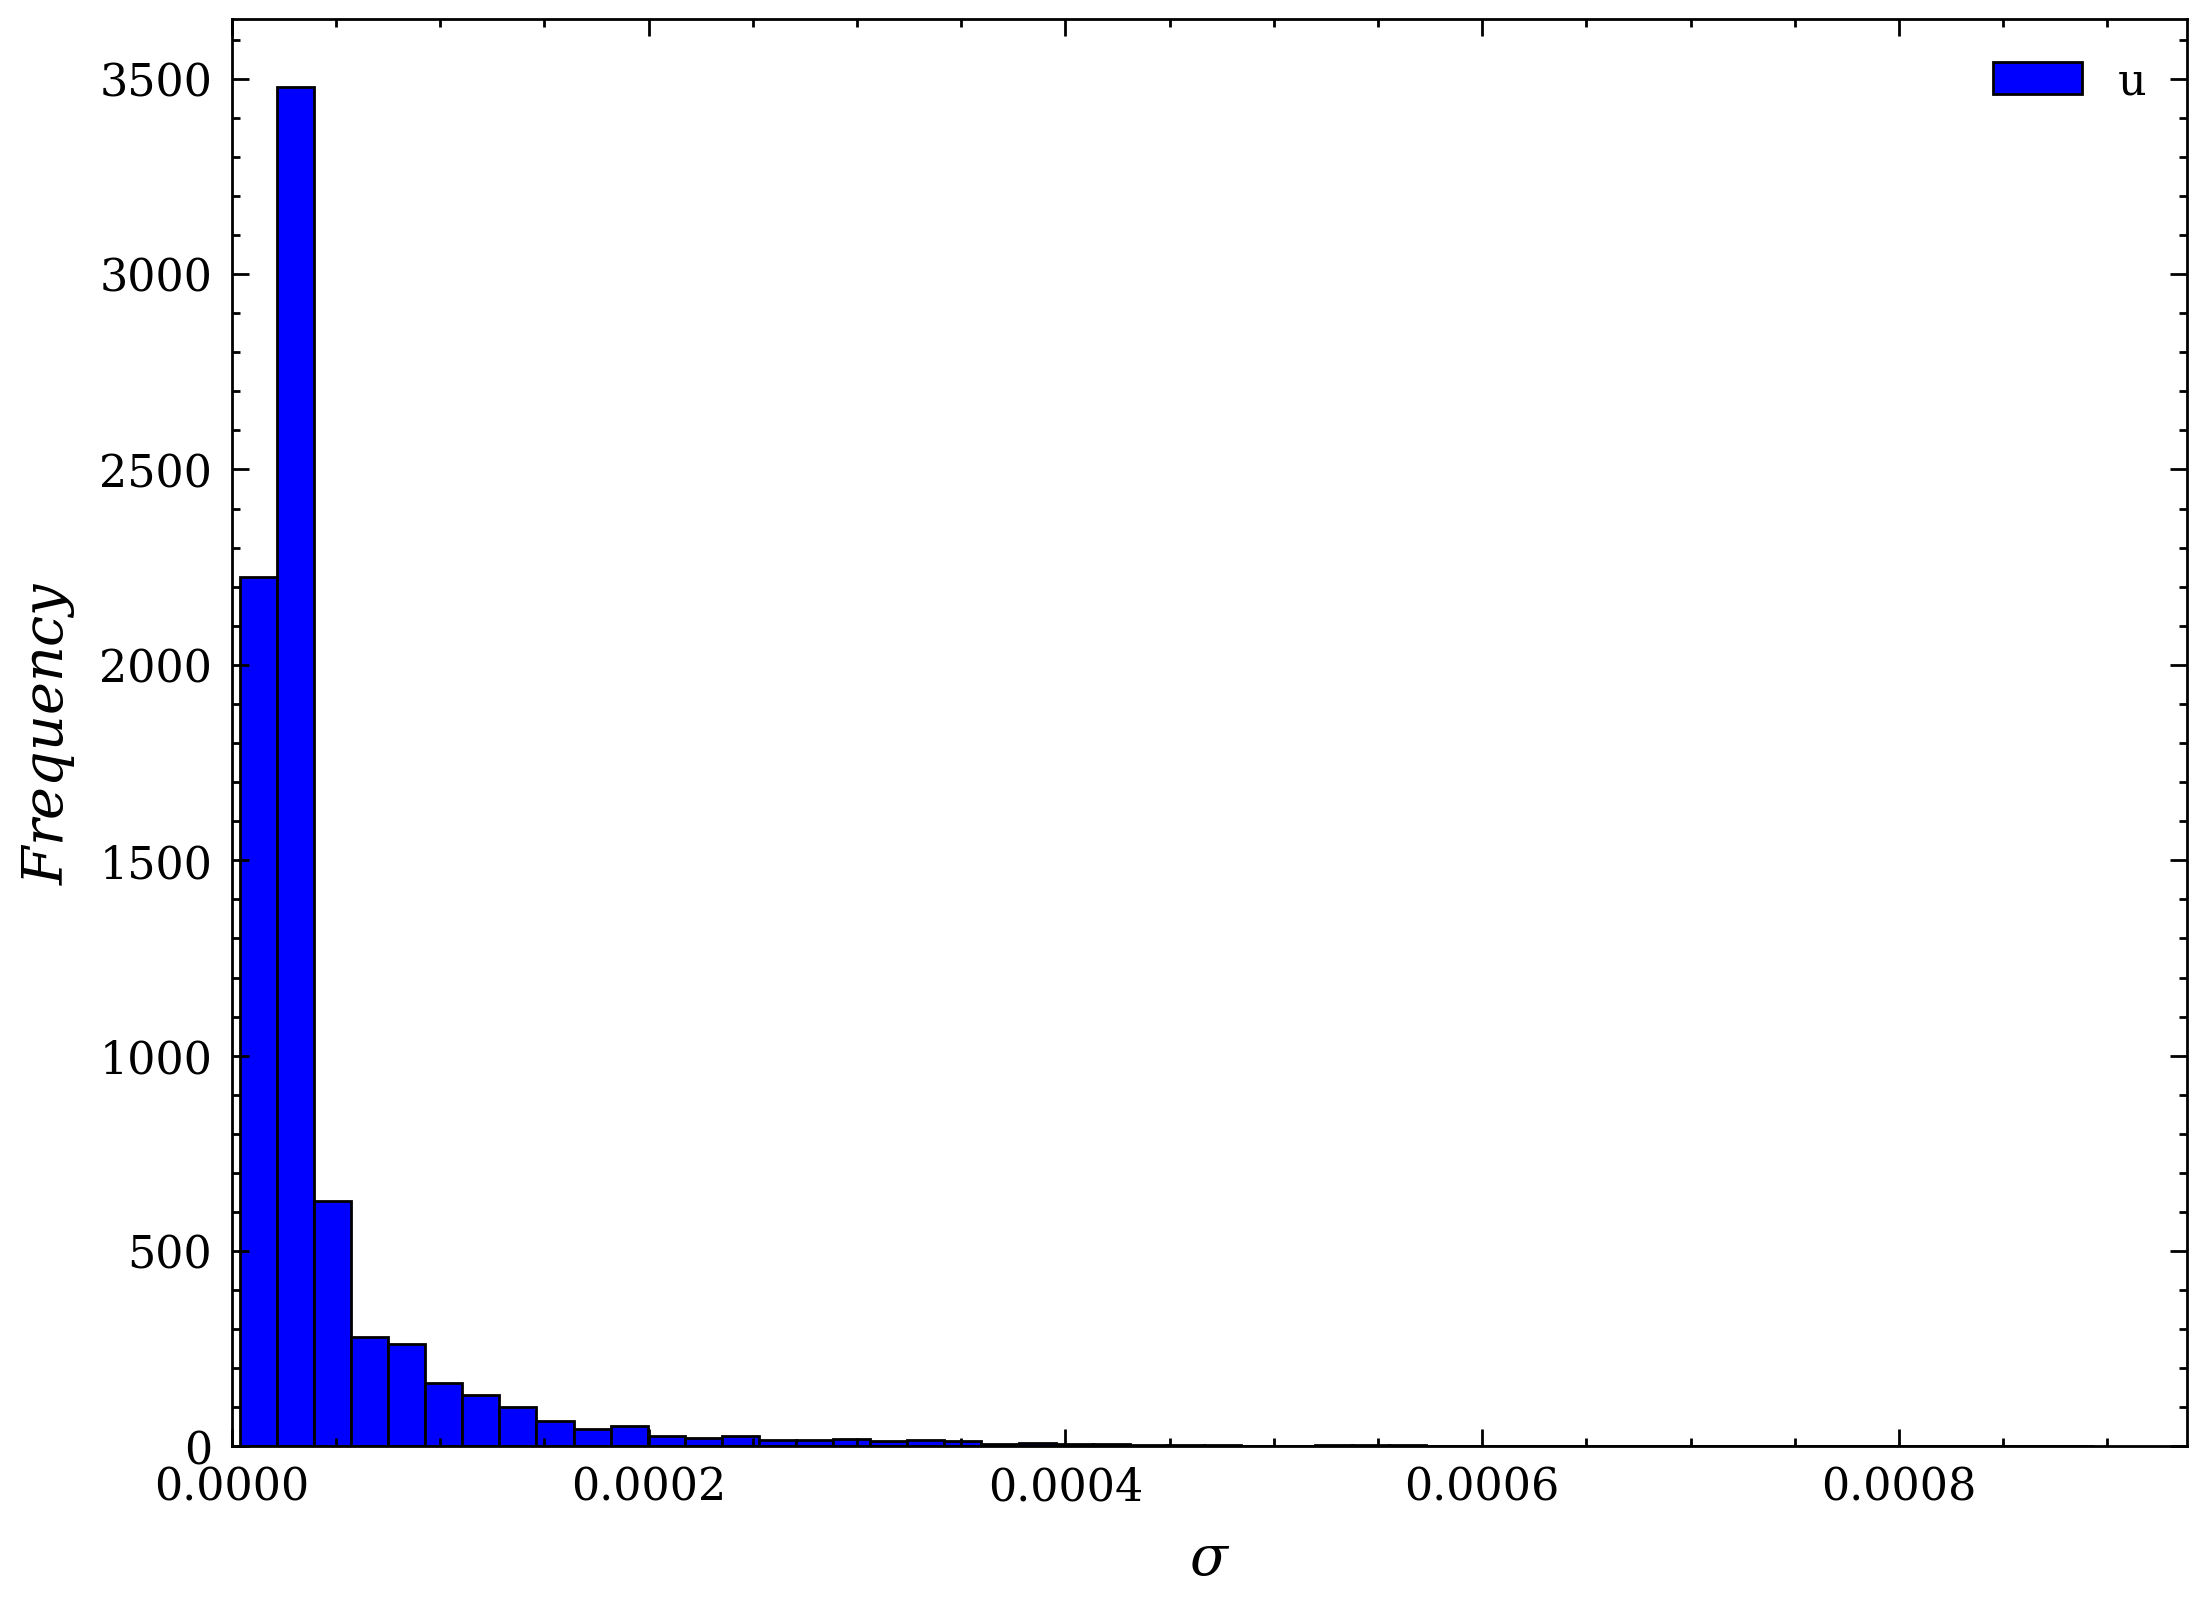

In [5]:
f1, ax1 = plt.subplots(1, 1)
ax1.hist(stn_dev_u[300,:,:].flatten(), bins = 50, color = 'blue', alpha = 1, label = 'u', edgecolor='black', linewidth=0.5)
ax1.set_xlabel(r'$\sigma$')
ax1.set_ylabel('$Frequency$')
ax1.set_xlim(0)
plt.legend(fontsize = 8)
plt.show()

Plotting a histogram of two different rotation rates

In [6]:
dir = 'G:/Testing/RPM-12.0__Upiston-100__Stroke-100/2023-08-21__FPS-90/'
u_rot, v_rot = oj.load_multiple_rings(dir, 10)
u_rot, v_rot = oj.scaleVelNozzle(u_rot, v_rot, 90)

stn_dev_u_rot = np.std(u_rot[1:,:,:,:], axis = 0)
stn_dev_v_rot = np.std(v_rot[1:,:,:,:], axis = 0)

Filtered Data Imported  -  (2699, 69, 111)
G:/Testing/RPM-12.0__Upiston-100__Stroke-100/2023-08-21__FPS-90/ 
Filtered Data Imported  -  (2699, 69, 111)
[####                                    ]10%Filtered Data Imported  -  (2699, 69, 111)
[########                                ]20%Filtered Data Imported  -  (2699, 69, 111)
[############                            ]30%Filtered Data Imported  -  (2699, 69, 111)
[################                        ]40%Filtered Data Imported  -  (2699, 69, 111)
[####################                    ]50%Filtered Data Imported  -  (2699, 69, 111)
[########################                ]60%Filtered Data Imported  -  (2699, 69, 111)
[############################            ]70%Filtered Data Imported  -  (2699, 69, 111)
[################################        ]80%Filtered Data Imported  -  (2699, 69, 111)
[####################################    ]90%Filtered Data Imported  -  (2699, 69, 111)
[########################################]100%

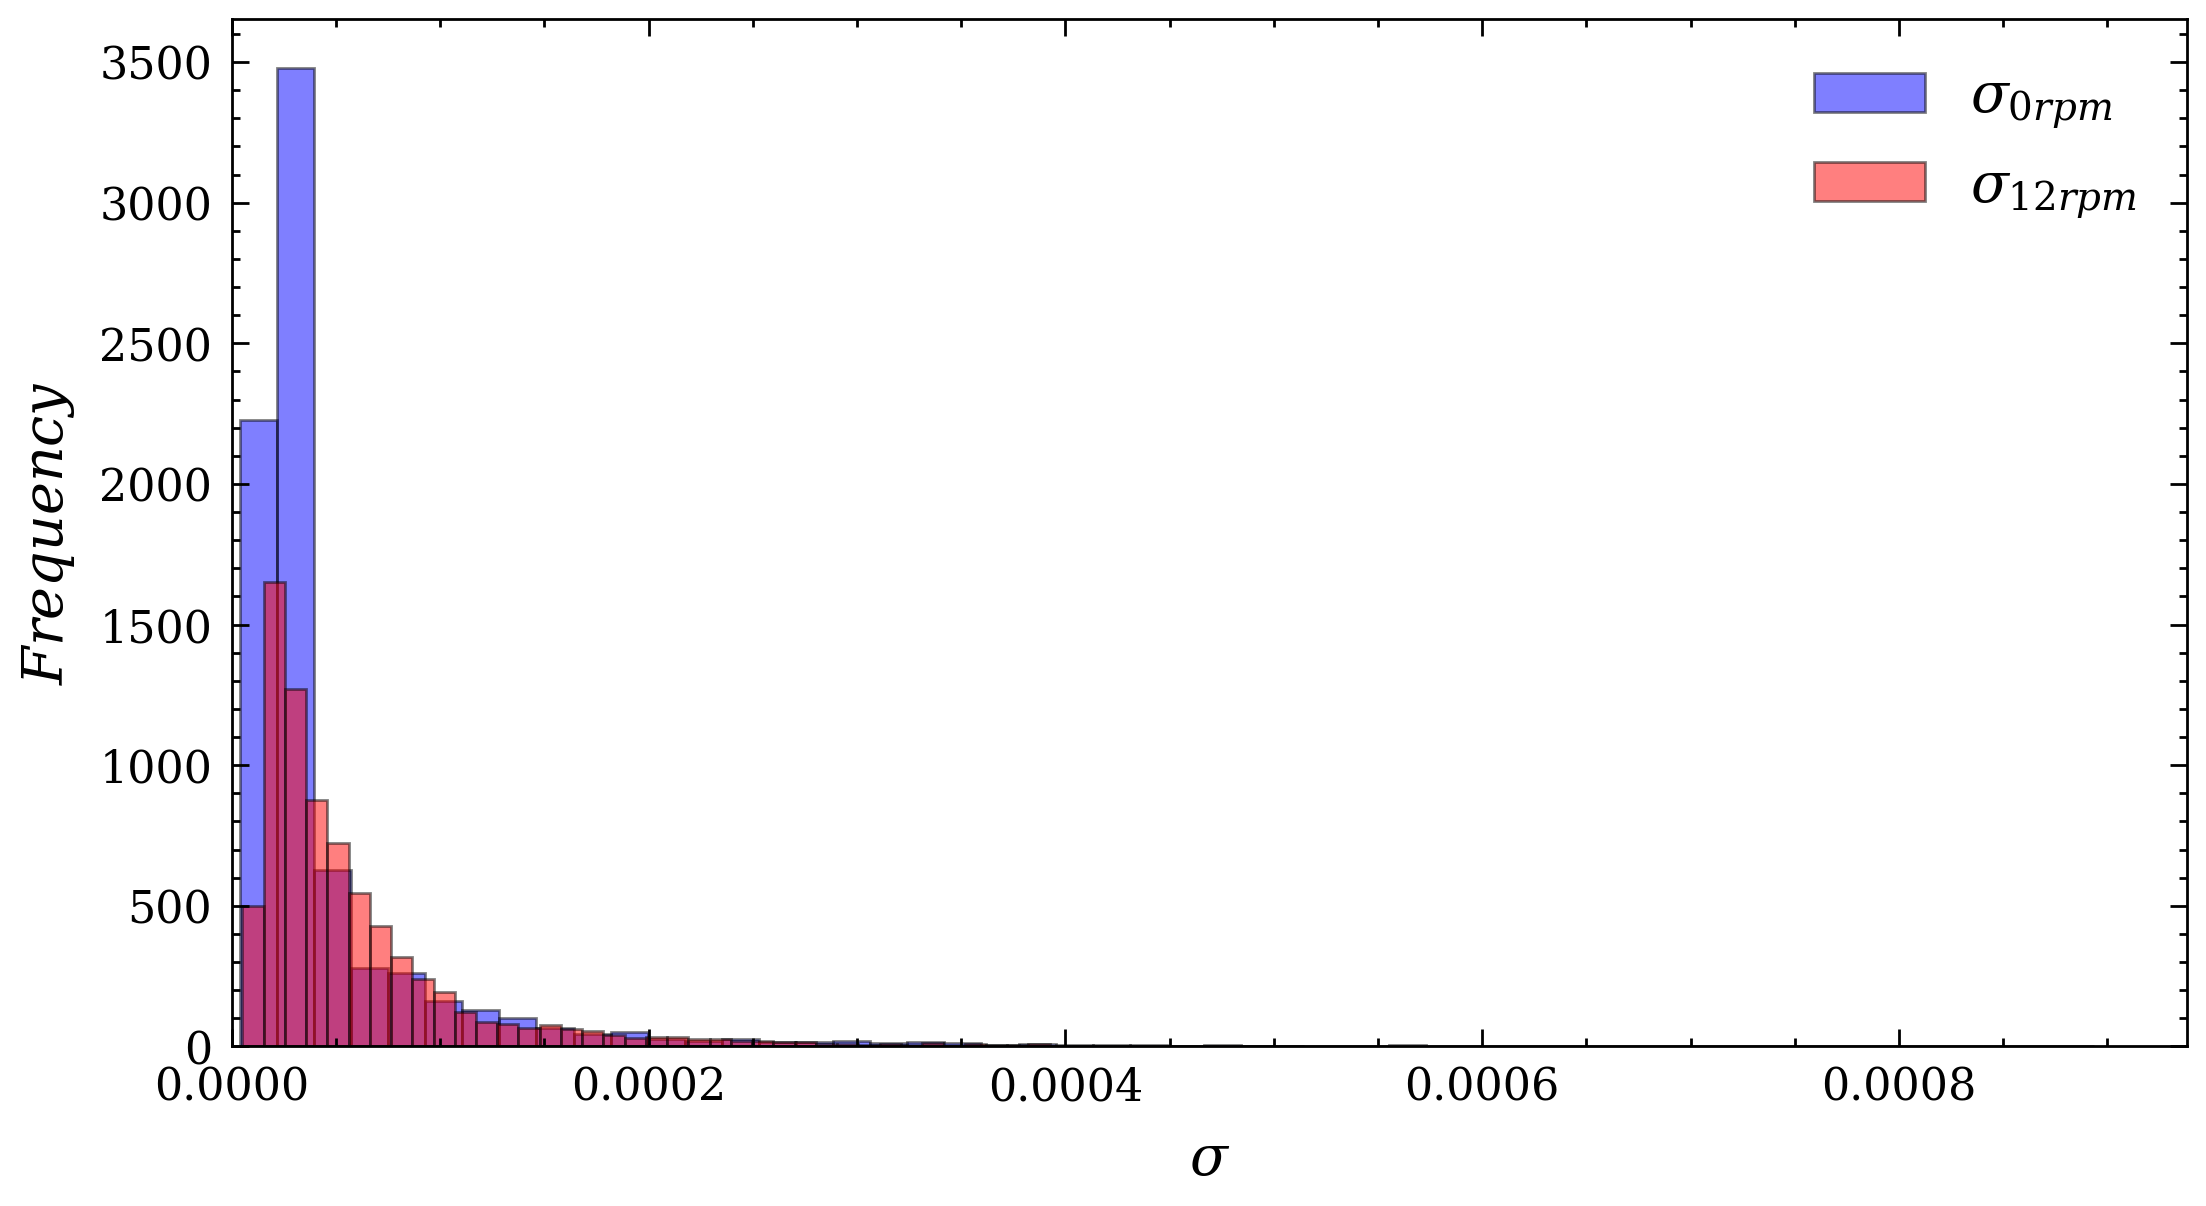

In [7]:
f1, ax1 = plt.subplots(1, 1, figsize=(5.5, 3))
ax1.hist(stn_dev_u[300,:,:].flatten(), bins = 50, color = 'blue', alpha = 0.5, label = r'$\sigma_{0rpm}$', edgecolor='black', linewidth=0.5)
ax1.hist(stn_dev_u_rot[300,:,:].flatten(), bins = 50, color = 'red', alpha = 0.5, label = r'$\sigma_{12rpm}$', edgecolor='black', linewidth=0.5)
ax1.set_xlabel(r'$\sigma$')
ax1.set_ylabel('$Frequency$')
ax1.set_xlim(0)
plt.legend()
plt.show()

Loading in multiple rotation rates

In [8]:
dirs_list = [
    'G:/Testing/RPM-0.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/',
    'G:/Testing/RPM-1.0__Upiston-100__Stroke-100/2023-08-23__FPS-90/',
    'G:/Testing/RPM-2.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/',
    'G:/Testing/RPM-3.0__Upiston-100__Stroke-100/2023-08-24__FPS-90/',
    'G:/Testing/RPM-6.0__Upiston-100__Stroke-100/2023-08-18__FPS-90/',
    'G:/Testing/RPM-9.0__Upiston-100__Stroke-100/2023-08-19__FPS-90/',
    'G:/Testing/RPM-12.0__Upiston-100__Stroke-100/2023-08-21__FPS-90/',
]
stn_dev_max = np.zeros([len(dirs_list), u.shape[1]])
stn_dev_mean = np.zeros([len(dirs_list), u.shape[1]])

for i in range(len(dirs_list)):
    u, v = oj.load_multiple_rings(dirs_list[i], 10)
    u, v = oj.scaleVelNozzle(u, v, 90)
    stn_dev = np.std(u[1:,:,:,:], axis = 0)
    for j in range(u.shape[1]):
        stn_dev_max[i, j] = np.max(stn_dev[j,:,:])
        stn_dev_mean[i, j] = np.mean(stn_dev[j,:,:])


Filtered Data Imported  -  (2699, 69, 111)
G:/Testing/RPM-0.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/ 
Filtered Data Imported  -  (2699, 69, 111)
[####                                    ]10%Filtered Data Imported  -  (2699, 69, 111)
[########                                ]20%Filtered Data Imported  -  (2699, 69, 111)
[############                            ]30%Filtered Data Imported  -  (2699, 69, 111)
[################                        ]40%Filtered Data Imported  -  (2699, 69, 111)
[####################                    ]50%Filtered Data Imported  -  (2699, 69, 111)
[########################                ]60%Filtered Data Imported  -  (2699, 69, 111)
[############################            ]70%Filtered Data Imported  -  (2699, 69, 111)
[################################        ]80%Filtered Data Imported  -  (2699, 69, 111)
[####################################    ]90%Filtered Data Imported  -  (2699, 69, 111)
[########################################]100%Filtered Da

[5.14701345e-05 5.33412165e-05 6.18154643e-05 ... 6.71669995e-05
 6.47827019e-05 8.82775949e-05]


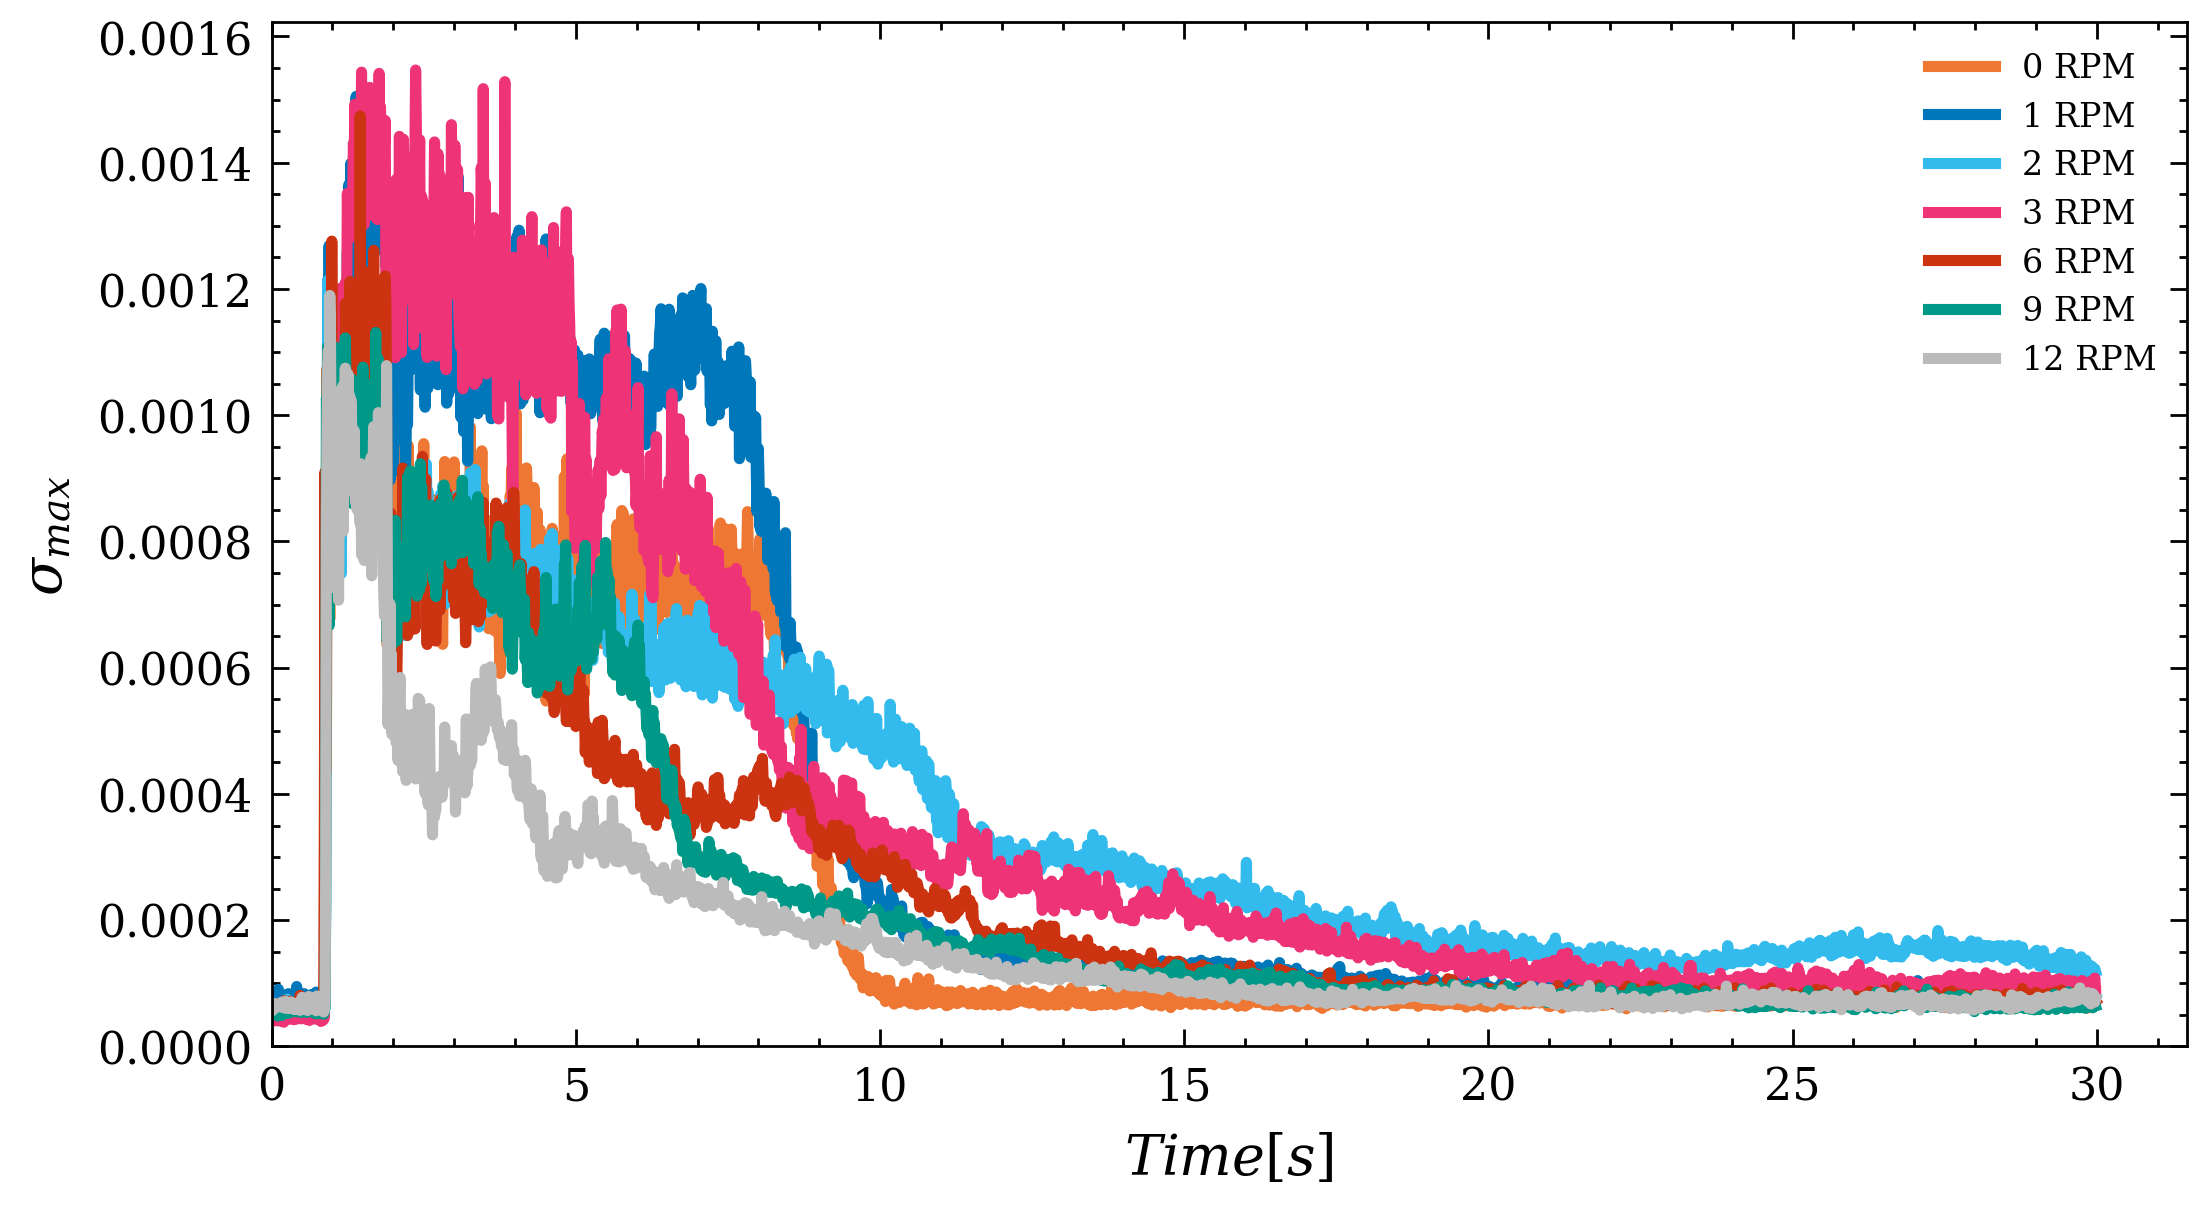

In [9]:
print(stn_dev_max[0,:])
f2, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(5.5, 3))
ax2.plot(Time, stn_dev_max[0,:], label = '0 RPM')
ax2.plot(Time, stn_dev_max[1,:], label = '1 RPM')
ax2.plot(Time, stn_dev_max[2,:], label = '2 RPM')
ax2.plot(Time, stn_dev_max[3,:], label = '3 RPM')
ax2.plot(Time, stn_dev_max[4,:], label = '6 RPM')
ax2.plot(Time, stn_dev_max[5,:], label = '9 RPM')
ax2.plot(Time, stn_dev_max[6,:], label = '12 RPM')
ax2.set_xlabel('$Time [s]$')
ax2.set_ylabel(r'$\sigma_{max}$')
ax2.set_ylim(bottom=0)
ax2.set_xlim(0)
plt.legend(fontsize = 6)
plt.show()

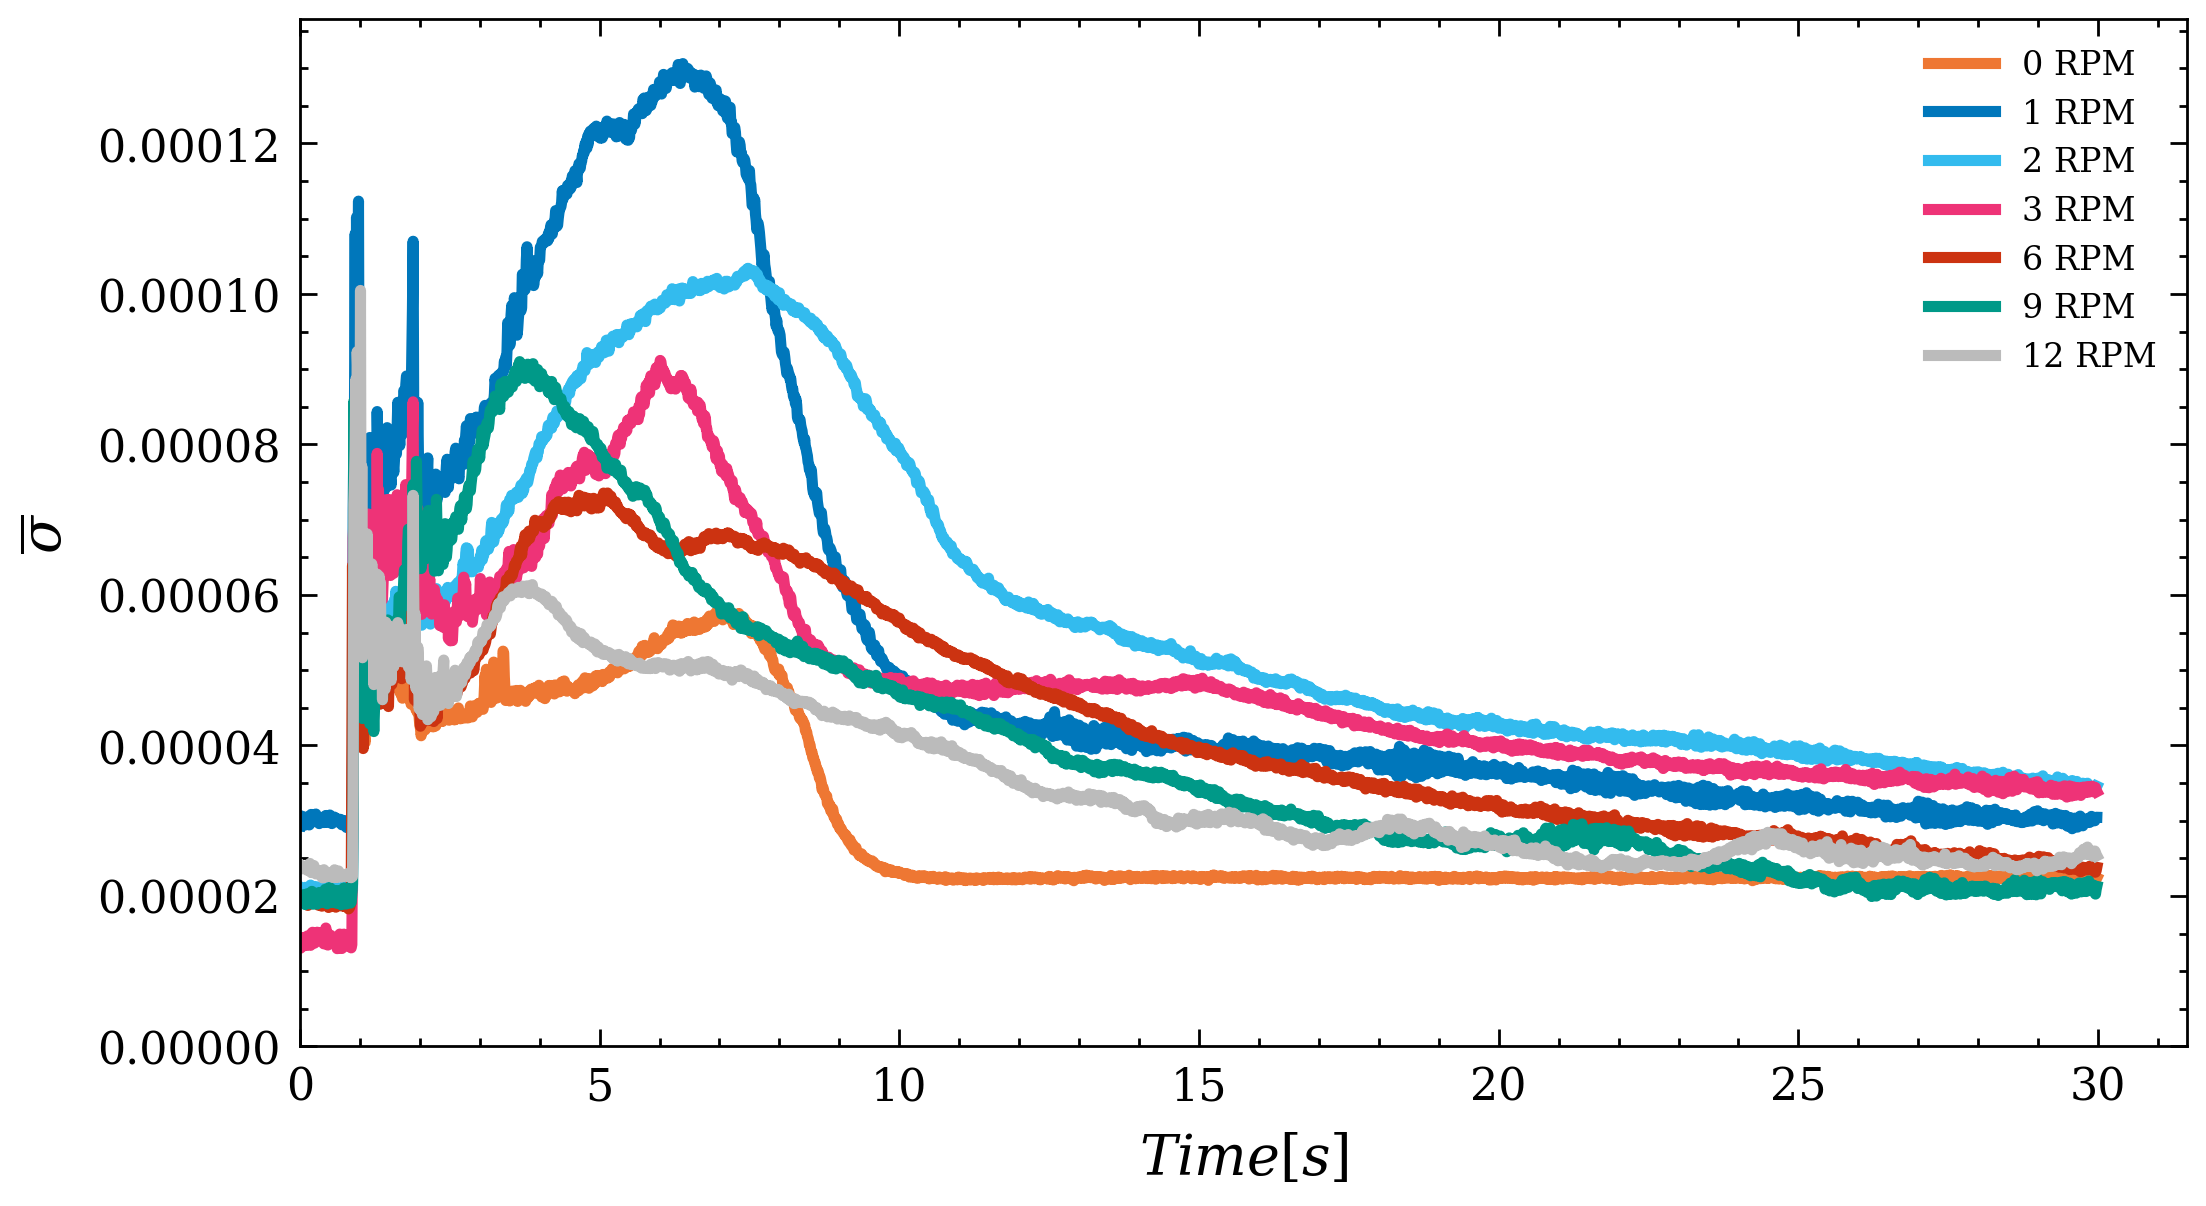

: 

In [ ]:
f3, ax3 = plt.subplots(nrows=1, ncols=1, figsize=(5.5, 3))
ax3.plot(Time, stn_dev_mean[0,:], label = '0 RPM')
ax3.plot(Time, stn_dev_mean[1,:], label = '1 RPM')
ax3.plot(Time, stn_dev_mean[2,:], label = '2 RPM')
ax3.plot(Time, stn_dev_mean[3,:], label = '3 RPM')
ax3.plot(Time, stn_dev_mean[4,:], label = '6 RPM')
ax3.plot(Time, stn_dev_mean[5,:], label = '9 RPM')
ax3.plot(Time, stn_dev_mean[6,:], label = '12 RPM')
ax3.set_xlabel('$Time [s]$')
ax3.set_ylabel(r'$\overline{\sigma}$')
ax3.set_ylim(bottom=0)
ax3.set_xlim(0)
plt.legend(fontsize = 6)
plt.show()